# Repetition Lag-Rank

> Decompose temporal organization by which presentation of a repeated item a transition originates from.

For each qualifying transition from an item studied at least twice with sufficient spacing, the absolute lag from each study position is ranked among all available lags from that position. A score of 0.5 indicates chance; scores above 0.5 reflect temporal contiguity. Comparing scores across presentation indices reveals whether transitions cluster around the first or second occurrence.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.replagrank import plot_rep_lagrank
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
yticks = None
trial_query = "data['list_type'] > 2"
min_lag = 4
size = 2
color_cycle = None
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

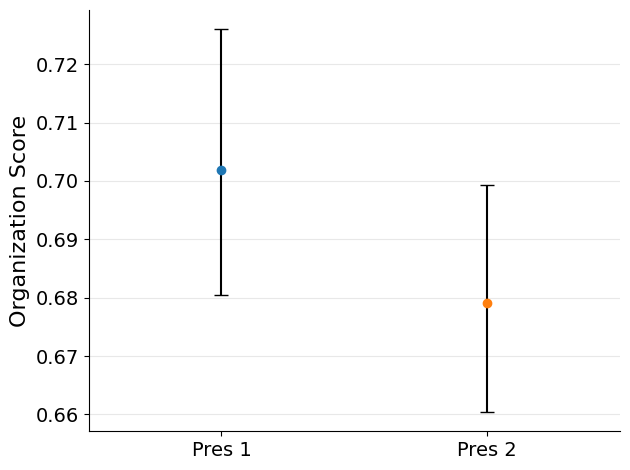

In [4]:
plot_rep_lagrank(
    data,
    trial_mask,
    min_lag=min_lag,
    size=size,
    color_cycle=color_cycle,
    confidence_level=confidence_level,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
if yticks is not None:
    for ax in plt.gcf().axes:
        ax.set_yticks(yticks)
save_figure(figure_dir, figure_str)

## Interpretation

Each point represents a temporal factor score for a given presentation index.

- **Scores above 0.5**: transitions from that presentation are temporally organized.
- **Higher score for second presentation**: transitions cluster around the more recent occurrence.
- **Similar scores**: both presentations contribute equally to temporal contiguity.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset` with repeated items.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits for the point plot, or `None` for automatic scaling.
- `yticks` — y-axis ticks for the point plot, or `None` for automatic ticks.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `min_lag` — minimum spacing (intervening items) between repeated presentations.
- `size` — maximum number of study positions a single item can occupy.
- `color_cycle` — point colors, or `None` for the default cycle. For list-type plots, use `["#2ca02c", "#ff4d4d", "#4da3df"]`.
- `confidence_level` — confidence level for subject-wise error bars.